# 16 — Does a vimentin scar contain lesions? Day ~30 vs chronic peak

Suggestion from a collaborator: a successful astrocyte scar may be a good sign for recovery because it restricts
immune infiltration. Notebooks 11–12 found more lesion-astrocyte vimentin in milder / resolving disease. Here:

1. **Time.** Lesion borders at the chronic peak (PEAK1, d13–18) vs around day 30 post-induction: chronic MILD16 /
   SEVERE16 (d27–29) and RR PEAK2_MILD / PEAK2 / MONOPHASIC (d31–33). Does a vimentin border build between peak and
   d30, and does it differ by outcome?
2. **Containment.** Each lesion as an object: vimentin strength at its border, and how many infiltrating immune cells
   (T, B, NK/DC, DC, monocyte-derived macrophages, neutrophils; not microglia) sit just **outside** it relative to
   inside ("leakage"). The decisive comparison is **between lesions of the same animal** (same image, staining,
   disease stage): do better-bordered lesions leak less?
3. **The tissue**: strongly vs weakly bordered deep lesions within the same piece, for several animals.

Lesion objects: control-referenced lesion cells (notebook 10) linked within 30 µm in the same tissue piece, ≥ 100
cells. Border band: −30 to +30 µm around the lesion edge. Perilesional zone: non-lesion cells 0–50 µm outside the
object. Image readouts use 18S-segmented cells ≥ 20 µm from another piece; vimentin as robust z within image.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components
from scipy.spatial import cKDTree
from scipy.stats import mannwhitneyu, spearmanr, wilcoxon

from beyondboundaries import data, plotting
from beyondboundaries.io import XeniumBundle, find_bundles

plotting.style()
SRC = "notebooks/16_scar_containment.ipynb"
OUT = ROOT / "results" / "16_scar_containment"
OUT.mkdir(parents=True, exist_ok=True)
COL = plotting.CATEGORICAL
PX = 0.2125
IMMUNE = ["T cell", "B cell", "NK/DC", "DC", "MDM", "Neutrophil"]

In [2]:
a = ad.read_h5ad(ROOT / "data" / "RRMAP2_all_runs.h5ad", backed="r")
obs = a.obs[["sample_name", "meta_sample_id", "sample_id", "stage", "model", "day_of_sacrifice", "Anno_L1_curated",
             "x_centroid", "y_centroid"]].copy()
a.file.close()
obs["stage"] = obs.stage.astype(str)
obs["arm"] = np.where(obs.model.astype(str).str.startswith("CHRONIC"), "chronic", "RR")
obs = obs.join(pd.read_parquet(ROOT / "data" / "lesion10" / "lesion_calls.parquet"))
obs["les"] = obs.lesion_state.str.startswith("S")
obs["immune"] = obs.ctype.isin(IMMUNE)
clin = pd.read_csv(ROOT / "data" / "clinical" / "animal_course_metrics.csv", index_col=0)

fa = pd.read_parquet(ROOT / "data" / "features_norm_all.parquet",
                     columns=["section_id", "segmentation_method", "smavim_cell_mean", "smavim_terr_mean",
                              "centroid_x_px", "centroid_y_px", "label"])
fa = fa[fa.segmentation_method == "Segmented by interior stain (18S)"]


def zimg(s, by):
    med = s.groupby(by, observed=True).transform("median")
    mad = (s - med).abs().groupby(by, observed=True).transform("median") * 1.4826
    return (s - med) / mad.replace(0, np.nan)


fa["vim_z"] = zimg(fa.smavim_cell_mean, fa.section_id)
fa["terr_vim_z"] = zimg(fa.smavim_terr_mean, fa.section_id)
obs = obs.join(fa[["vim_z", "terr_vim_z"]])

# cells < 20 µm from another tissue piece: excluded from image readouts (pieces touch in runs 1-3)
other = pd.Series(np.inf, index=obs.index)
for _, g in obs.groupby("sample_id", observed=True):
    xy, pc = g[["x_centroid", "y_centroid"]].to_numpy(), g.meta_sample_id.astype(str).to_numpy()
    for p in np.unique(pc):
        m = pc == p
        if not m.all():
            other[g.index[m]] = cKDTree(xy[~m]).query(xy[m])[0]
obs.loc[other < 20, ["vim_z", "terr_vim_z"]] = np.nan
print(len(obs), "cells")

1384881 cells


## Lesion objects and their borders

In [3]:
rows = []
cell_obj = pd.Series(-1, index=obs.index)
cell_dist = pd.Series(np.nan, index=obs.index)  # signed: + inside, - outside
for pc, g in obs[obs.lesion_state != "not scored"].groupby("meta_sample_id", observed=True):
    L, N = g[g.les], g[~g.les]
    if len(L) < 100 or len(N) < 100:
        continue
    xyL, xyN = L[["x_centroid", "y_centroid"]].to_numpy(), N[["x_centroid", "y_centroid"]].to_numpy()
    pairs = cKDTree(xyL).query_pairs(30.0, output_type="ndarray")
    _, lab = connected_components(coo_matrix((np.ones(len(pairs)), (pairs[:, 0], pairs[:, 1])),
                                             shape=(len(L), len(L))), directed=False)
    size = np.bincount(lab)
    keep = size[lab] >= 100
    lab_id = np.array([f"{pc}#{x}" for x in lab])
    cell_obj[L.index[keep]] = lab_id[keep]
    cell_dist[L.index] = cKDTree(xyN).query(xyL)[0]          # depth inside
    dN, iL = cKDTree(xyL).query(xyN)                           # outside: distance to nearest lesion cell
    cell_dist[N.index] = -dN
    near = (dN <= 50) & keep[iL]
    cell_obj[N.index[near]] = lab_id[iL[near]]                 # perilesional cells belong to the nearest object
obs["obj"], obs["edge_um"] = cell_obj, cell_dist

o = obs[obs.obj != -1]
inside = o.les
band = o.edge_um.between(-30, 30)
ast = o.Anno_L1_curated == "Astrocyte"
g_in, g_out = o[inside].groupby("obj"), o[~inside].groupby("obj")
objs = pd.DataFrame({
    "sample_name": o.groupby("obj").sample_name.first(),
    "size": g_in.size(),
    "active share": g_in.lesion_state.agg(lambda s: s.str[:2].isin(["S1", "S4"]).mean()),
    "immune inside": g_in.immune.mean(),
    "immune outside (0–50 µm)": g_out.immune.mean(),
    "n outside": g_out.size(),
    "border astro vimentin": o[band & ast].groupby("obj").vim_z.median(),
    "n border astro": o[band & ast].groupby("obj").vim_z.count(),
    "border tissue vimentin": o[band].groupby("obj").terr_vim_z.median(),
    "core astro vimentin": o[(o.edge_um > 60) & ast].groupby("obj").vim_z.median(),
})
objs["leakage"] = np.log2((objs["immune outside (0–50 µm)"] + 0.005) / (objs["immune inside"] + 0.005))
an = obs.groupby("sample_name", observed=True).agg(stage=("stage", "first"), arm=("arm", "first"),
                                                   day=("day_of_sacrifice", "first"))
objs = objs.join(an, on="sample_name").join(clin[["score", "first_peak"]], on="sample_name")
objs = objs[(objs["n outside"] >= 30)]
objs.to_csv(OUT / "lesion_objects.csv")
print(len(objs), "lesion objects in", objs.sample_name.nunique(), "animals")
objs.describe().T[["50%", "min", "max"]].round(3)

/tmp/ipykernel_12562/1543832729.py:15: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['C2_G1_Bot_0#0' 'C2_G1_Bot_0#1' 'C2_G1_Bot_0#1' ... 'C2_G1_Bot_0#1'
 'C2_G1_Bot_0#1' 'C2_G1_Bot_0#1']' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cell_obj[L.index[keep]] = lab_id[keep]


419 lesion objects in 53 animals


,50%,min,max
size,311.000,100.000,15890.000
active share,0.167,0.000,0.807
immune inside,0.178,0.008,0.573
immune outside (0–50 µm),0.033,0.000,0.147
n outside,100.000,30.000,1433.000
border astro vimentin,1.686,-1.429,36.727
n border astro,17.000,1.000,335.000
border tissue vimentin,0.285,-2.058,22.573
core astro vimentin,2.334,-2.552,39.687
leakage,-2.199,-6.575,1.268


## 1. Day ~30 vs chronic peak
Per animal: median over its lesion objects (size-weighted where noted) of border astrocyte vimentin, border tissue
vimentin and leakage.

In [4]:
GROUP30 = {"chronic PEAK1 (d13–18)": lambda d: (d.stage == "PEAK1") & (d.arm == "chronic"),
           "RR PEAK1 (d14–18)": lambda d: (d.stage == "PEAK1") & (d.arm == "RR"),
           "MILD16 (d27–28)": lambda d: d.stage == "MILD16", "SEVERE16 (d28–29)": lambda d: d.stage == "SEVERE16",
           "PEAK2_MILD (d31)": lambda d: d.stage == "PEAK2_MILD", "PEAK2 (d32–33)": lambda d: d.stage == "PEAK2",
           "MONOPHASIC (d32–33)": lambda d: d.stage == "MONOPHASIC"}
pa = objs.groupby("sample_name").apply(lambda g: pd.Series({
    "border astro vimentin": np.average(g["border astro vimentin"].fillna(g["border astro vimentin"].median()),
                                        weights=g["size"]) if g["border astro vimentin"].notna().any() else np.nan,
    "border tissue vimentin": np.average(g["border tissue vimentin"].fillna(0), weights=g["size"]),
    "leakage": np.average(g.leakage, weights=g["size"]),
    "immune outside (0–50 µm)": np.average(g["immune outside (0–50 µm)"], weights=g["size"]),
    "objects": len(g)}), include_groups=False).join(an).join(clin[["score"]])
pa.to_csv(OUT / "per_animal.csv")
rows = []
for gname, f in GROUP30.items():
    d = pa[f(pa)]
    rows.append({"group": gname, "animals": len(d), **d[["border astro vimentin", "border tissue vimentin", "leakage",
                                                          "immune outside (0–50 µm)", "objects"]].median().to_dict()})
tab30 = pd.DataFrame(rows).set_index("group")
tab30.round(3)

,animals,border astro vimentin,border tissue vimentin,leakage,immune outside (0–50 µm),objects
group,,,,,,
chronic PEAK1 (d13–18),6,0.583,0.038,-3.596,0.028,4.0
RR PEAK1 (d14–18),4,0.005,-0.173,-4.117,0.019,3.5
MILD16 (d27–28),3,2.646,0.968,-1.541,0.046,4.0
SEVERE16 (d28–29),3,0.758,0.017,-2.154,0.043,9.0
PEAK2_MILD (d31),2,3.836,0.626,-2.457,0.044,19.0
PEAK2 (d32–33),2,1.223,0.295,-3.230,0.033,7.0
MONOPHASIC (d32–33),4,5.041,2.913,-2.387,0.049,9.0


PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/16_scar_containment/day30_vs_peak.png')

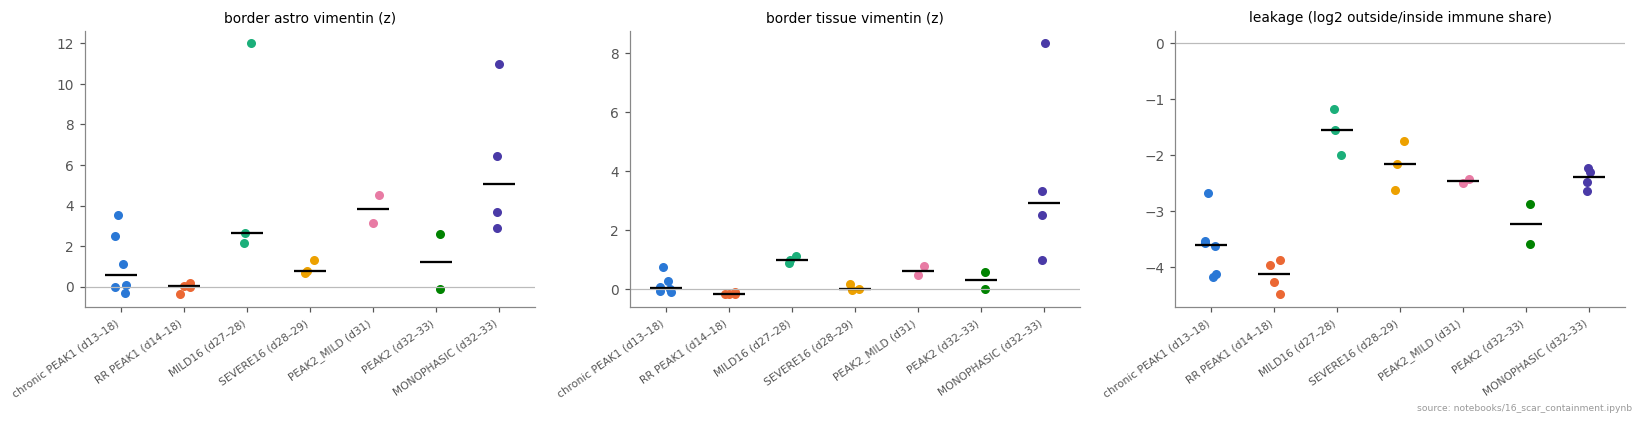

In [5]:
fig, axs = plt.subplots(1, 3, figsize=(15, 3.8))
for ax, c in zip(axs, ["border astro vimentin", "border tissue vimentin", "leakage"]):
    for k, (gname, f) in enumerate(GROUP30.items()):
        v = pa[f(pa)][c].dropna()
        ax.scatter(np.full(len(v), k) + np.random.default_rng(k).uniform(-0.1, 0.1, len(v)), v, s=24,
                   color=COL[k % 8])
        ax.hlines(v.median(), k - 0.25, k + 0.25, color="black", lw=1.5)
    ax.set_xticks(range(len(GROUP30)), list(GROUP30), rotation=35, ha="right", fontsize=7)
    ax.axhline(0, color="#bbbbbb", lw=0.8)
    ax.set_title(c + (" (log2 outside/inside immune share)" if c == "leakage" else " (z)"), fontsize=9)
fig.tight_layout()
plotting.save_fig(fig, "day30_vs_peak", OUT, SRC)

In [6]:
cmp = []
for a_, b_ in [("chronic PEAK1 (d13–18)", "MILD16 (d27–28)"), ("chronic PEAK1 (d13–18)", "SEVERE16 (d28–29)"),
               ("MILD16 (d27–28)", "SEVERE16 (d28–29)"), ("MONOPHASIC (d32–33)", "PEAK2 (d32–33)"),
               ("MONOPHASIC (d32–33)", "PEAK2_MILD (d31)"), ("RR PEAK1 (d14–18)", "MONOPHASIC (d32–33)")]:
    for c in ["border astro vimentin", "border tissue vimentin", "leakage"]:
        x, y = pa[GROUP30[a_](pa)][c].dropna(), pa[GROUP30[b_](pa)][c].dropna()
        if len(x) >= 2 and len(y) >= 2:
            cmp.append(dict(a=a_, b=b_, measure=c, med_a=x.median(), med_b=y.median(), n=f"{len(x)}+{len(y)}",
                            p=mannwhitneyu(x, y).pvalue))
pd.DataFrame(cmp).round(3)

,a,b,measure,med_a,med_b,n,p
0,chronic PEAK1 (d13–18),MILD16 (d27–28),border astro vimentin,0.583,2.646,6+3,0.167
1,chronic PEAK1 (d13–18),MILD16 (d27–28),border tissue vimentin,0.038,0.968,6+3,0.024
2,chronic PEAK1 (d13–18),MILD16 (d27–28),leakage,-3.596,-1.541,6+3,0.024
3,chronic PEAK1 (d13–18),SEVERE16 (d28–29),border astro vimentin,0.583,0.758,6+3,0.905
4,chronic PEAK1 (d13–18),SEVERE16 (d28–29),border tissue vimentin,0.038,0.017,6+3,1.000
5,chronic PEAK1 (d13–18),SEVERE16 (d28–29),leakage,-3.596,-2.154,6+3,0.024
6,MILD16 (d27–28),SEVERE16 (d28–29),border astro vimentin,2.646,0.758,3+3,0.100
7,MILD16 (d27–28),SEVERE16 (d28–29),border tissue vimentin,0.968,0.017,3+3,0.100
8,MILD16 (d27–28),SEVERE16 (d28–29),leakage,-1.541,-2.154,3+3,0.200
9,MONOPHASIC (d32–33),PEAK2 (d32–33),border astro vimentin,5.041,1.223,4+2,0.133


## 2. Containment: across lesions of the same animal
For every animal with ≥ 5 lesion objects (that have border astrocytes): Spearman ρ between border vimentin and
leakage across its lesions. Negative ρ = better-bordered lesions leak fewer immune cells. Then the same after
removing, within each animal, what lesion size and activity (share of active S1/S4 tissue) explain.

In [7]:
def within_animal(df, x, y, adjust=False, min_obj=5):
    out = {}
    for an_, g in df.groupby("sample_name"):
        g = g[[x, y, "size", "active share"]].dropna()
        if len(g) < min_obj:
            continue
        xx, yy = g[x].to_numpy(), g[y].to_numpy()
        if adjust:
            Z = np.c_[np.ones(len(g)), np.log(g["size"]), g["active share"]]
            xx = xx - Z @ np.linalg.lstsq(Z, xx, rcond=None)[0]
            yy = yy - Z @ np.linalg.lstsq(Z, yy, rcond=None)[0]
        out[an_] = spearmanr(xx, yy).statistic
    return pd.Series(out)


rows = []
for x in ["border astro vimentin", "border tissue vimentin"]:
    for adj in (False, True):
        r = within_animal(objs, x, "leakage", adj).dropna()
        rows.append(dict(border=x, adjusted_for_size_and_activity=adj, animals=len(r), median_rho=r.median(),
                         share_negative=(r < 0).mean(), wilcoxon_p=wilcoxon(r).pvalue if len(r) >= 6 else np.nan))
        if x == "border tissue vimentin" and adj:
            rho_tissue_adj = r
cont = pd.DataFrame(rows)
cont.to_csv(OUT / "within_animal_containment.csv", index=False)
cont.round(3)

,border,adjusted_for_size_and_activity,animals,median_rho,share_negative,wilcoxon_p
0,border astro vimentin,False,37,0.143,0.324,0.014
1,border astro vimentin,True,37,0.093,0.459,0.281
2,border tissue vimentin,False,37,0.200,0.297,0.002
3,border tissue vimentin,True,37,0.214,0.378,0.046


PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/16_scar_containment/within_animal_containment.png')

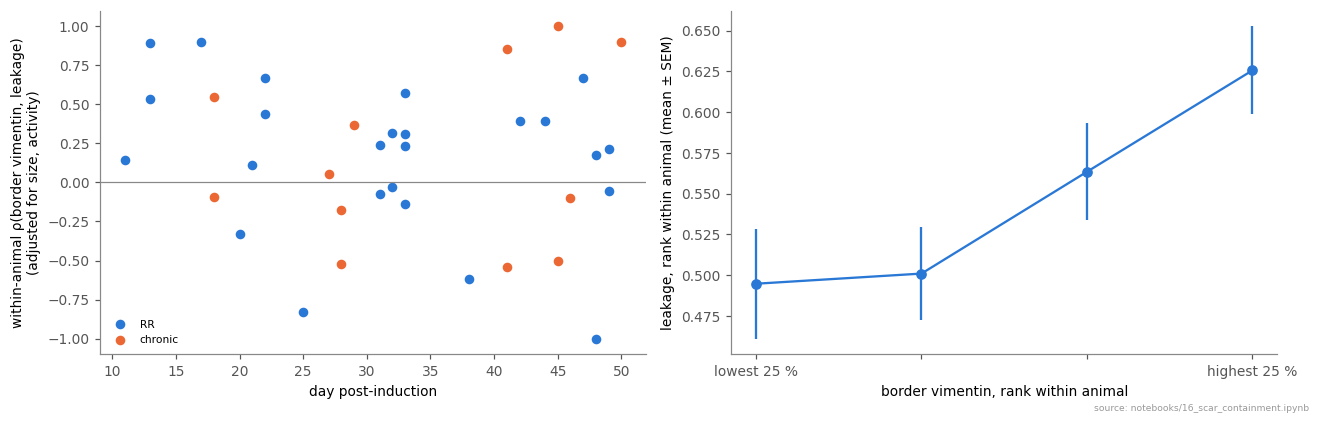

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(12, 3.8))
r = within_animal(objs, "border tissue vimentin", "leakage", True).dropna().to_frame("rho").join(an)
for k, (arm, g) in enumerate(r.groupby("arm")):
    axs[0].scatter(g.day, g.rho, s=28, color=COL[k], label=arm)
axs[0].axhline(0, color="#888888", lw=0.8)
axs[0].set(xlabel="day post-induction", ylabel="within-animal ρ(border vimentin, leakage)\n(adjusted for size, activity)")
axs[0].legend(fontsize=7)
# pooled view: within-animal ranks
oo = objs.dropna(subset=["border tissue vimentin", "leakage"]).copy()
oo["vim_rank"] = oo.groupby("sample_name")["border tissue vimentin"].rank(pct=True)
oo["leak_rank"] = oo.groupby("sample_name")["leakage"].rank(pct=True)
oo = oo[oo.groupby("sample_name").leakage.transform("size") >= 5]
bins = pd.cut(oo.vim_rank, [0, 0.25, 0.5, 0.75, 1.0])
m = oo.groupby(bins, observed=True).leak_rank.agg(["mean", "sem"])
axs[1].errorbar(range(4), m["mean"], m["sem"], marker="o", color=COL[0])
axs[1].set_xticks(range(4), ["lowest 25 %", "", "", "highest 25 %"])
axs[1].set(xlabel="border vimentin, rank within animal", ylabel="leakage, rank within animal (mean ± SEM)")
fig.tight_layout()
plotting.save_fig(fig, "within_animal_containment", OUT, SRC)

## 2b. A fairer containment test
The leakage ratio (outside ÷ inside immune share) rises when a lesion empties of immune cells while resolving, even
if nothing escapes, and vimentin is highest in resolving lesions; so the ratio confounds "leaky" with "resolving".
Three better measures:

- **Escape**: immune share 0–50 µm outside the lesion relative to the same animal's distant healthy tissue
  (> 150 µm from any lesion): log2 ratio; 0 = no excess immune cells around the lesion.
- **Edge spike** (vimentin ring, notebook 15): tissue vimentin 0–10 µm inside the edge minus the mean of
  −30…−10 µm (outside) and +20…+45 µm (inside).
- **Immune profile across the edge**, for each animal's lesions split at its median edge spike.

In [9]:
far = obs[obs.edge_um < -150].groupby("sample_name", observed=True).immune.mean()
objs["escape"] = np.log2((objs["immune outside (0–50 µm)"] + 0.002) / (objs.sample_name.map(far) + 0.002))
o = obs[obs.obj != -1]
z0 = o[o.edge_um.between(0, 10, inclusive="right")].groupby("obj").terr_vim_z.median()
zo = o[o.edge_um.between(-30, -10)].groupby("obj").terr_vim_z.median()
zi = o[o.edge_um.between(20, 45)].groupby("obj").terr_vim_z.median()
objs["edge spike"] = z0 - (zo + zi) / 2
objs.to_csv(OUT / "lesion_objects.csv")

rows = []
for x in ["edge spike", "border tissue vimentin", "border astro vimentin"]:
    for y in ["escape", "immune outside (0–50 µm)"]:
        for adj in (False, True):
            r = within_animal(objs, x, y, adj).dropna()
            rows.append(dict(border=x, outcome=y, adjusted=adj, animals=len(r), median_rho=r.median(),
                             share_negative=(r < 0).mean(), wilcoxon_p=wilcoxon(r).pvalue if len(r) >= 6 else np.nan))
cont2 = pd.DataFrame(rows)
cont2.to_csv(OUT / "within_animal_containment_v2.csv", index=False)
cont2.round(3)

,border,outcome,adjusted,animals,median_rho,share_negative,wilcoxon_p
0,edge spike,escape,False,37,0.300,0.378,0.008
1,edge spike,escape,True,37,0.200,0.243,0.029
2,edge spike,immune outside (0–50 µm),False,37,0.300,0.378,0.008
3,edge spike,immune outside (0–50 µm),True,37,0.200,0.324,0.054
4,border tissue vimentin,escape,False,37,0.386,0.216,0.000
5,border tissue vimentin,escape,True,37,0.420,0.189,0.000
6,border tissue vimentin,immune outside (0–50 µm),False,37,0.386,0.216,0.000
7,border tissue vimentin,immune outside (0–50 µm),True,37,0.381,0.216,0.001
8,border astro vimentin,escape,False,37,0.452,0.135,0.000
9,border astro vimentin,escape,True,37,0.300,0.189,0.006


In [10]:
# per animal: edge spike (size-weighted) by group
pa["edge spike"] = objs.groupby("sample_name").apply(
    lambda g: np.average(g["edge spike"].fillna(0), weights=g["size"]), include_groups=False)
pa["escape"] = objs.groupby("sample_name").apply(lambda g: np.average(g.escape, weights=g["size"]),
                                                 include_groups=False)
pd.DataFrame({gname: pa[f(pa)][["edge spike", "escape"]].median() for gname, f in GROUP30.items()}).T.round(2)

,edge spike,escape
chronic PEAK1 (d13–18),0.21,0.18
RR PEAK1 (d14–18),0.26,2.90
MILD16 (d27–28),0.97,2.27
SEVERE16 (d28–29),0.00,2.29
PEAK2_MILD (d31),1.74,2.35
PEAK2 (d32–33),1.24,-0.20
MONOPHASIC (d32–33),4.55,2.27


PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/16_scar_containment/immune_profile_by_edge_vimentin.png')

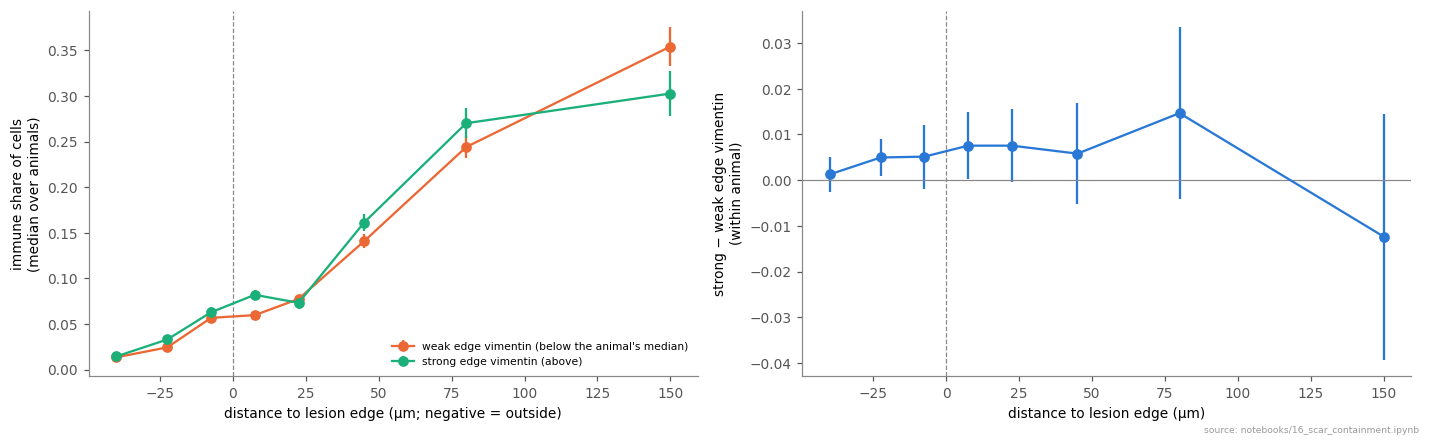

In [11]:
EB = [-150, -100, -70, -50, -30, -15, 0, 15, 30, 60, 100, 200]
o = obs[obs.obj.isin(objs.index)].copy()
o["edge_bin"] = pd.cut(o.edge_um, EB)
o = o.join(objs[["edge spike", "sample_name"]].rename(columns={"sample_name": "_an"}), on="obj")
o["spike_hi"] = o.groupby("_an")["edge spike"].transform(lambda s: s > s.median())
prof = o.groupby(["_an", "spike_hi", "edge_bin"], observed=True).immune.mean().unstack("edge_bin").reindex(
    columns=o.edge_bin.cat.categories)
mids = [(a_ + b_) / 2 for a_, b_ in zip(EB[:-1], EB[1:])]
fig, axs = plt.subplots(1, 2, figsize=(13, 4))
for k, (lab, c) in enumerate([("weak edge vimentin (below the animal's median)", COL[1]),
                              ("strong edge vimentin (above)", COL[2])]):
    p = prof.xs(k == 1, level="spike_hi")
    axs[0].errorbar(mids, p.median(), yerr=p.sem(), marker="o", color=c, label=lab)
axs[0].axvline(0, color="#888888", ls="--", lw=0.8)
axs[0].set(xlabel="distance to lesion edge (µm; negative = outside)", ylabel="immune share of cells\n(median over animals)")
axs[0].legend(fontsize=7)
diff = (prof.xs(True, level="spike_hi") - prof.xs(False, level="spike_hi"))
axs[1].errorbar(mids, diff.median(), yerr=diff.sem(), marker="o", color=COL[0])
axs[1].axhline(0, color="#888888", lw=0.8); axs[1].axvline(0, color="#888888", ls="--", lw=0.8)
axs[1].set(xlabel="distance to lesion edge (µm)", ylabel="strong − weak edge vimentin\n(within animal)")
fig.tight_layout()
plotting.save_fig(fig, "immune_profile_by_edge_vimentin", OUT, SRC)

## 2c. Surface confound: deep lesions only
The best-bordered lesion above runs along the cord surface, where vimentin is naturally high (glia limitans,
astrocyte end-feet at the pia) and immune cells enter from the meninges. So border vimentin and immune cells around a
lesion can both just reflect closeness to the surface. Repeat the within-animal tests (i) on lesions whose cells
lie a median > 100 µm from the tissue edge, and (ii) on all lesions with that depth as an extra covariate.

In [12]:
pia = pd.read_parquet(ROOT / "data" / "features_norm_all.parquet", columns=["edge_um"]).edge_um.rename("pia_um")
obs = obs.join(pia)
objs["lesion depth from surface (µm)"] = obs[obs.les & (obs.obj != -1)].groupby("obj").pia_um.median()


def within_animal_depth(df, x, y, min_obj=5):
    out = {}
    for an_, g in df.groupby("sample_name"):
        g = g[[x, y, "size", "active share", "lesion depth from surface (µm)"]].dropna()
        if len(g) < min_obj:
            continue
        Z = np.c_[np.ones(len(g)), np.log(g["size"]), g["active share"], np.log1p(g["lesion depth from surface (µm)"])]
        xx = g[x].to_numpy() - Z @ np.linalg.lstsq(Z, g[x].to_numpy(), rcond=None)[0]
        yy = g[y].to_numpy() - Z @ np.linalg.lstsq(Z, g[y].to_numpy(), rcond=None)[0]
        out[an_] = spearmanr(xx, yy).statistic
    return pd.Series(out)


deep = objs[objs["lesion depth from surface (µm)"] > 100]
print(f"deep lesions: {len(deep)} of {len(objs)}")
rows = []
for x in ["edge spike", "border tissue vimentin", "border astro vimentin"]:
    for lab, r in [("deep lesions only (adj. size, activity)", within_animal(deep, x, "escape", True, min_obj=4)),
                   ("all lesions, adj. size, activity, depth", within_animal_depth(objs, x, "escape"))]:
        r = r.dropna()
        rows.append(dict(border=x, analysis=lab, animals=len(r), median_rho=r.median(), share_negative=(r < 0).mean(),
                         wilcoxon_p=wilcoxon(r).pvalue if len(r) >= 6 else np.nan))
cont3 = pd.DataFrame(rows)
cont3.to_csv(OUT / "within_animal_containment_depth.csv", index=False)
cont3.round(3)

deep lesions: 243 of 419


,border,analysis,animals,median_rho,share_negative,wilcoxon_p
0,edge spike,"deep lesions only (adj. size, activity)",30,0.236,0.367,0.270
1,edge spike,"all lesions, adj. size, activity, depth",37,0.193,0.351,0.451
2,border tissue vimentin,"deep lesions only (adj. size, activity)",30,0.312,0.267,0.031
3,border tissue vimentin,"all lesions, adj. size, activity, depth",37,0.253,0.243,0.003
4,border astro vimentin,"deep lesions only (adj. size, activity)",30,0.446,0.233,0.041
5,border astro vimentin,"all lesions, adj. size, activity, depth",37,0.254,0.324,0.154


In [13]:
print("does depth drive both? across all lesions:",
      {c: round(spearmanr(np.log1p(objs['lesion depth from surface (µm)']), objs[c], nan_policy='omit').statistic, 2)
       for c in ["border tissue vimentin", "edge spike", "escape"]})

does depth drive both? across all lesions: {'border tissue vimentin': np.float64(-0.44), 'edge spike': np.float64(-0.22), 'escape': np.float64(-0.34)}


## 3. The tissue: strongly vs weakly bordered deep lesions in the same piece
Pairs of **deep** lesions (median > 100 µm from the cord surface, so no glia limitans; ≥ 300 cells) in the same tissue
piece, for the three animals with the largest within-piece difference in border tissue vimentin. αSMA/vimentin channel
(magma, 0.43 µm/px, same image and contrast within a row), the lesion outline (cyan; lesion cells rasterised at 4 µm,
closed by 10 µm) and infiltrating immune cells (small red dots). The measured border is the band ±30 µm around the
cyan line.

PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/16_scar_containment/best_vs_worst_bordered_lesion.png')

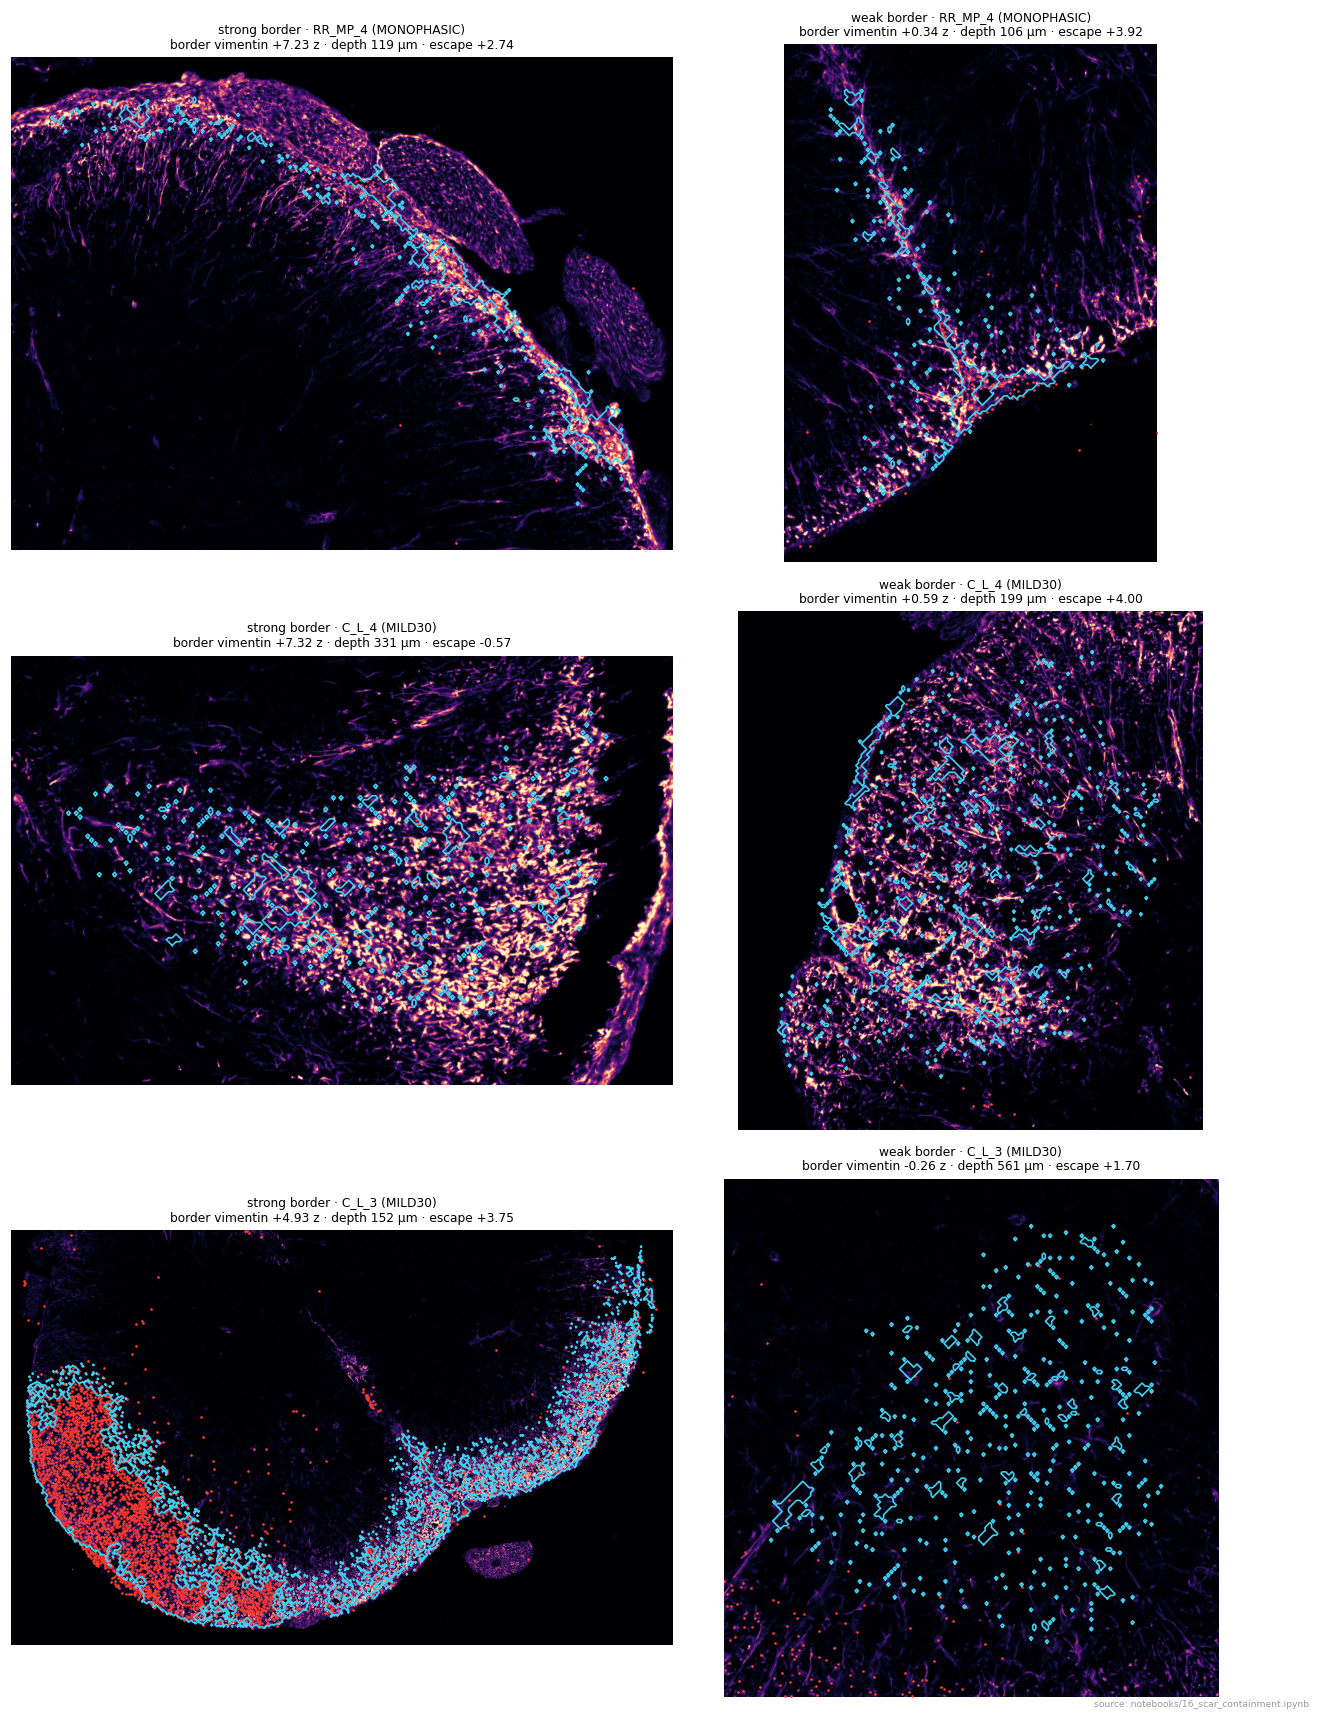

In [14]:
from skimage.measure import find_contours
from scipy import ndimage as ndi_

bundles = find_bundles(data.load_config())
dd = objs[(objs["lesion depth from surface (µm)"] > 100) & (objs["size"] >= 300)].dropna(
    subset=["border tissue vimentin"]).copy()
dd["piece"] = dd.index.str.split("#").str[0]
sp = dd.groupby("piece")["border tissue vimentin"].agg(lambda s: s.max() - s.min() if len(s) >= 2 else np.nan).dropna()
sp = sp.sort_values(ascending=False)
pieces, seen = [], set()
for pc in sp.index:
    an_ = dd[dd.piece == pc].sample_name.iloc[0]
    if an_ not in seen:
        pieces.append(pc); seen.add(an_)
    if len(pieces) == 3:
        break


def outline(ax, cells, x0, y0, step=4.0, close_um=10):
    gx = ((cells.x_centroid - x0) / step).astype(int).to_numpy()
    gy = ((cells.y_centroid - y0) / step).astype(int).to_numpy()
    m = np.zeros((gy.max() + 3, gx.max() + 3), bool)
    m[gy + 1, gx + 1] = True
    m = ndi_.binary_closing(m, iterations=max(1, int(close_um / step)))
    m = ndi_.binary_fill_holes(m)
    for cnt in find_contours(m.astype(float), 0.5):
        ax.plot(x0 + (cnt[:, 1] - 1) * step, y0 + (cnt[:, 0] - 1) * step, color="#3fd0f0", lw=1.1)


lv, f = 1, 2
fig, axs = plt.subplots(len(pieces), 2, figsize=(12, 5.2 * len(pieces)))
axs = np.atleast_2d(axs)
for r, pc in enumerate(pieces):
    cand = dd[dd.piece == pc]
    hi_o, lo_o = cand["border tissue vimentin"].idxmax(), cand["border tissue vimentin"].idxmin()
    sec = obs[obs.meta_sample_id == pc].sample_id.iloc[0]
    vim_img = XeniumBundle(bundles[str(sec)]).read_level("smavim", lv)
    crops = []
    for ob in (hi_o, lo_o):
        c = obs[(obs.obj == ob) & obs.les]
        pad = 60
        x0, x1 = c.x_centroid.min() - pad, c.x_centroid.max() + pad
        y0, y1 = c.y_centroid.min() - pad, c.y_centroid.max() + pad
        sl = (slice(max(int(y0 / (PX * f)), 0), int(y1 / (PX * f))), slice(max(int(x0 / (PX * f)), 0), int(x1 / (PX * f))))
        crops.append((ob, c, x0, x1, y0, y1, vim_img[sl]))
    hiv = np.percentile(np.concatenate([cr[-1].ravel() for cr in crops]), 99.5)
    for k, (ob, c, x0, x1, y0, y1, im) in enumerate(crops):
        ax = axs[r, k]
        ax.imshow(np.clip(im / hiv, 0, 1), cmap="magma", extent=(x0, x1, y1, y0))
        outline(ax, c, x0, y0)
        w = obs[(obs.meta_sample_id == pc) & obs.immune & obs.x_centroid.between(x0, x1) & obs.y_centroid.between(y0, y1)]
        ax.scatter(w.x_centroid, w.y_centroid, s=3, color="#ff3b30", lw=0)
        ax.set_xlim(x0, x1); ax.set_ylim(y1, y0); ax.axis("off")
        o_ = objs.loc[ob]
        ax.set_title(f"{'strong' if k == 0 else 'weak'} border · {o_.sample_name} ({o_.stage})\n"
                     f"border vimentin {o_['border tissue vimentin']:+.2f} z · depth "
                     f"{o_['lesion depth from surface (µm)']:.0f} µm · escape {o_.escape:+.2f}", fontsize=8)
fig.tight_layout()
plotting.save_fig(fig, "best_vs_worst_bordered_lesion", OUT, SRC)

## 4. Revision: lesion *regions* instead of linked cells
The figure above showed two problems with the cell-linkage objects: many are diffuse scatters of lesion-called cells
(no real outline, so "border" is ill-defined), and "depth" from the tissue mask is wrong where nerve roots or meninges
are attached. Revised definitions, per tissue piece on a 10 µm grid:

- **Lesion regions**: share of lesion cells among the cells in each grid square, smoothed (Gaussian σ = 15 µm, weighted
  by cell density), thresholded at 0.5 within tissue, holes filled; connected regions ≥ 0.005 mm² (50 squares) = lesions.
- **Signed distance to the region edge** for every cell (distance transform on the grid; + inside, − outside).
- **Depth from the cord surface**: the piece's tissue = grid squares with cells, closed by 30 µm and holes filled; the
  largest connected tissue component is the cord (drops detached roots/meninges); depth = distance to its outline.
- Per region: border tissue vimentin (−30…+30 µm), edge spike, escape (immune share 0–50 µm outside ÷ the animal's
  share > 150 µm from any region), size, active share, depth (median over the region's cells).

In [15]:
from scipy import ndimage as ndi_
from skimage.measure import label as sklabel

G = 10.0
cell_reg = pd.Series("-1", index=obs.index, dtype=object)
cell_sd = pd.Series(np.nan, index=obs.index)
cell_depth = pd.Series(np.nan, index=obs.index)
for pc, g in obs[obs.lesion_state != "not scored"].groupby("meta_sample_id", observed=True):
    if g.les.sum() < 100:
        continue
    gx = ((g.x_centroid - g.x_centroid.min()) / G).astype(int).to_numpy() + 3
    gy = ((g.y_centroid - g.y_centroid.min()) / G).astype(int).to_numpy() + 3
    H, W = gy.max() + 4, gx.max() + 4
    n_all = np.zeros((H, W)); n_les = np.zeros((H, W))
    np.add.at(n_all, (gy, gx), 1); np.add.at(n_les, (gy, gx), g.les.to_numpy().astype(float))
    tissue = ndi_.binary_fill_holes(ndi_.binary_closing(n_all > 0, iterations=3))
    lab_t = sklabel(tissue)
    if lab_t.max() == 0:
        continue
    cord = lab_t == np.argmax(np.bincount(lab_t.ravel())[1:]) + 1
    depth = ndi_.distance_transform_edt(cord) * G
    sm_all = ndi_.gaussian_filter(n_all, 1.5); sm_les = ndi_.gaussian_filter(n_les, 1.5)
    frac = np.where(sm_all > 1e-3, sm_les / np.maximum(sm_all, 1e-3), 0)
    les_mask = ndi_.binary_fill_holes((frac >= 0.5) & tissue)
    lab, nl = ndi_.label(les_mask)
    if nl == 0:
        continue
    sizes = np.bincount(lab.ravel())
    keep_lab = np.where(sizes >= 50)[0]
    keep_lab = keep_lab[keep_lab > 0]
    reg = np.where(np.isin(lab, keep_lab), lab, 0)
    din = ndi_.distance_transform_edt(reg > 0) * G
    dout, idx = ndi_.distance_transform_edt(reg == 0, return_indices=True)
    nearest = reg[idx[0], idx[1]]
    r_cell = np.where(reg[gy, gx] > 0, reg[gy, gx], np.where(dout[gy, gx] * G <= 50, nearest[gy, gx], 0))
    cell_reg[g.index] = np.where(r_cell > 0, np.array([f"{pc}@{x}" for x in r_cell], dtype=object), "-1")
    cell_sd[g.index] = np.where(reg[gy, gx] > 0, din[gy, gx], -dout[gy, gx] * G)
    cell_depth[g.index] = depth[gy, gx]
obs["reg"], obs["reg_dist"], obs["depth_um"] = cell_reg, cell_sd, cell_depth

o = obs[obs.reg != "-1"]
ins = o.reg_dist > 0
far_ = obs[obs.reg_dist < -150].groupby("sample_name", observed=True).immune.mean()
regs = pd.DataFrame({
    "sample_name": o.groupby("reg").sample_name.first(),
    "cells": o[ins].groupby("reg").size(),
    "active share": o[ins].groupby("reg").lesion_state.agg(lambda s: s.str[:2].isin(["S1", "S4"]).mean()),
    "lesion share inside": o[ins].groupby("reg").les.mean(),
    "depth (µm)": o[ins].groupby("reg").depth_um.median(),
    "border tissue vimentin": o[o.reg_dist.between(-30, 30)].groupby("reg").terr_vim_z.median(),
    "border astro vimentin": o[o.reg_dist.between(-30, 30) & (o.Anno_L1_curated == "Astrocyte")].groupby("reg").vim_z.median(),
    "immune outside": o[~ins].groupby("reg").immune.mean(),
    "n outside": o[~ins].groupby("reg").size(),
})
z0 = o[o.reg_dist.between(0.1, 10)].groupby("reg").terr_vim_z.median()
zo = o[o.reg_dist.between(-30, -10)].groupby("reg").terr_vim_z.median()
zi = o[o.reg_dist.between(20, 45)].groupby("reg").terr_vim_z.median()
regs["edge spike"] = z0 - (zo + zi) / 2
regs["escape"] = np.log2((regs["immune outside"] + 0.002) / (regs.sample_name.map(far_) + 0.002))
regs = regs.join(an, on="sample_name")
regs = regs[(regs.cells >= 100) & (regs["n outside"] >= 30)]
regs["size"] = regs.cells
regs["lesion depth from surface (µm)"] = regs["depth (µm)"]
regs.to_csv(OUT / "lesion_regions.csv")
print(f"{len(regs)} lesion regions in {regs.sample_name.nunique()} animals; median lesion share inside "
      f"{regs['lesion share inside'].median():.2f}; deep (> 100 µm): {(regs['depth (µm)'] > 100).sum()}")

356 lesion regions in 53 animals; median lesion share inside 0.96; deep (> 100 µm): 115


In [16]:
rows = []
for x in ["border tissue vimentin", "border astro vimentin", "edge spike"]:
    for lab_, df_, fn in [("all regions, adj. size, activity, depth", regs, lambda d, x: within_animal_depth(d, x, "escape")),
                          ("deep regions (> 100 µm), adj. size, activity",
                           regs[regs["depth (µm)"] > 100], lambda d, x: within_animal(d, x, "escape", True, min_obj=4))]:
        r = fn(df_, x).dropna()
        rows.append(dict(border=x, analysis=lab_, animals=len(r), median_rho=r.median(), share_negative=(r < 0).mean(),
                         wilcoxon_p=wilcoxon(r).pvalue if len(r) >= 6 else np.nan))
cont4 = pd.DataFrame(rows)
cont4.to_csv(OUT / "within_animal_containment_regions.csv", index=False)
cont4.round(3)

/tmp/ipykernel_12562/474927896.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for an_, g in df.groupby("sample_name"):
/tmp/ipykernel_12562/2489027575.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for an_, g in df.groupby("sample_name"):
/tmp/ipykernel_12562/474927896.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for an_, g in df.groupby("sample_name"):
/tmp/ipykernel_12562/2489027575.py:3: FutureWarning

,border,analysis,animals,median_rho,share_negative,wilcoxon_p
0,border tissue vimentin,"all regions, adj. size, activity, depth",36,0.000,0.472,0.650
1,border tissue vimentin,"deep regions (> 100 µm), adj. size, activity",10,-0.393,0.600,0.482
2,border astro vimentin,"all regions, adj. size, activity, depth",36,0.222,0.361,0.131
3,border astro vimentin,"deep regions (> 100 µm), adj. size, activity",10,-0.221,0.500,0.863
4,edge spike,"all regions, adj. size, activity, depth",36,0.102,0.472,0.771
5,edge spike,"deep regions (> 100 µm), adj. size, activity",10,1.000,0.300,0.084


In [17]:
def wavg(v, w):
    ok = v.notna() & w.notna() & (w > 0)
    return np.average(v[ok], weights=w[ok]) if ok.any() else np.nan


par = regs.groupby("sample_name").apply(lambda g: pd.Series({
    "border tissue vimentin": wavg(g["border tissue vimentin"], g["size"].astype(float)),
    "edge spike": wavg(g["edge spike"], g["size"].astype(float)),
    "escape": wavg(g.escape, g["size"].astype(float)), "regions": len(g)}), include_groups=False).join(an)
par.to_csv(OUT / "per_animal_regions.csv")
tab = pd.DataFrame({gname: par[f(par)][["border tissue vimentin", "edge spike", "escape", "regions"]].median()
                    for gname, f in GROUP30.items()}).T
tab["animals"] = [int(f(par).sum()) for f in GROUP30.values()]
cmp2 = []
for a_, b_ in [("chronic PEAK1 (d13–18)", "MILD16 (d27–28)"), ("chronic PEAK1 (d13–18)", "SEVERE16 (d28–29)"),
               ("MILD16 (d27–28)", "SEVERE16 (d28–29)"), ("MONOPHASIC (d32–33)", "PEAK2 (d32–33)"),
               ("RR PEAK1 (d14–18)", "MONOPHASIC (d32–33)")]:
    x, y = par[GROUP30[a_](par)]["border tissue vimentin"].dropna(), par[GROUP30[b_](par)]["border tissue vimentin"].dropna()
    if len(x) >= 2 and len(y) >= 2:
        cmp2.append(dict(a=a_, b=b_, med_a=x.median(), med_b=y.median(), n=f"{len(x)}+{len(y)}", p=mannwhitneyu(x, y).pvalue))
display(tab.round(2))
pd.DataFrame(cmp2).round(3)

/tmp/ipykernel_12562/3046500576.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  par = regs.groupby("sample_name").apply(lambda g: pd.Series({


,border tissue vimentin,edge spike,escape,regions,animals
chronic PEAK1 (d13–18),0.67,-0.56,-0.29,3.0,6
RR PEAK1 (d14–18),0.88,-1.36,-1.47,3.0,4
MILD16 (d27–28),0.50,-0.43,1.63,6.0,3
SEVERE16 (d28–29),0.02,0.03,1.74,7.0,3
PEAK2_MILD (d31),0.79,-1.42,0.04,12.5,2
PEAK2 (d32–33),1.87,-1.89,0.11,5.0,2
MONOPHASIC (d32–33),2.37,-2.50,1.72,11.5,4


,a,b,med_a,med_b,n,p
0,chronic PEAK1 (d13–18),MILD16 (d27–28),0.668,0.497,6+3,0.905
1,chronic PEAK1 (d13–18),SEVERE16 (d28–29),0.668,0.017,6+3,0.024
2,MILD16 (d27–28),SEVERE16 (d28–29),0.497,0.017,3+3,0.100
3,MONOPHASIC (d32–33),PEAK2 (d32–33),2.368,1.872,4+2,0.533
4,RR PEAK1 (d14–18),MONOPHASIC (d32–33),0.880,2.368,4+4,0.343


**Representative regions, not extremes.** Eight lesion regions drawn at random (seed 0) from day ~30 animals, each
with its outline (cyan), infiltrating immune cells (red) and the αSMA/vimentin channel (magma, per-row contrast).

PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/16_scar_containment/random_lesion_regions.png')

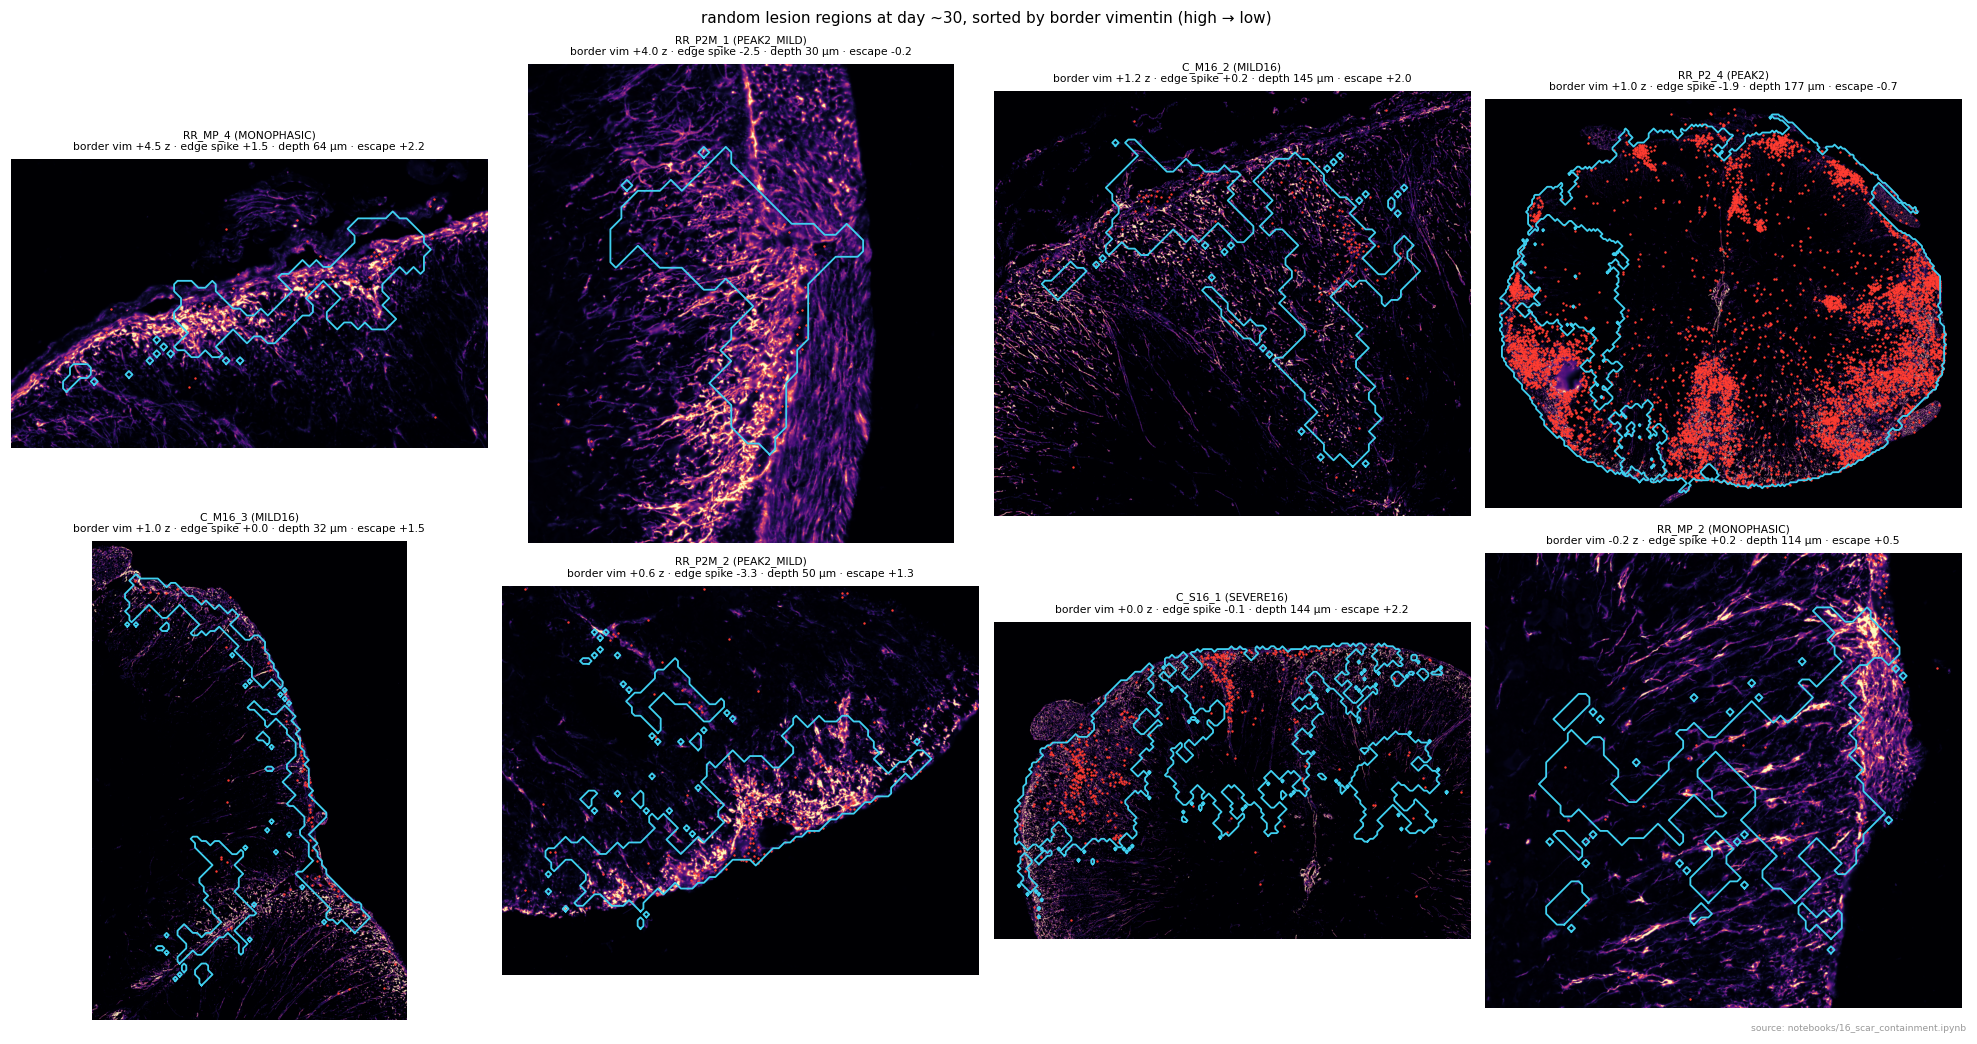

In [18]:
from skimage.measure import find_contours

pool = regs[regs.stage.isin(["MILD16", "SEVERE16", "PEAK2", "PEAK2_MILD", "MONOPHASIC"])].dropna(
    subset=["border tissue vimentin"])
pick = pool.sample(min(8, len(pool)), random_state=0).sort_values("border tissue vimentin", ascending=False)
fig, axs = plt.subplots(2, 4, figsize=(18, 9.5))
lv, f = 1, 2
cache_img = {}
for ax, (rid, rr) in zip(axs.ravel(), pick.iterrows()):
    pc = rid.split("@")[0]
    sec = str(obs[obs.meta_sample_id == pc].sample_id.iloc[0])
    if sec not in cache_img:
        cache_img[sec] = XeniumBundle(bundles[sec]).read_level("smavim", lv)
    vim_img = cache_img[sec]
    c = obs[(obs.reg == rid) & (obs.reg_dist > 0)]
    pad = 80
    x0, x1 = c.x_centroid.min() - pad, c.x_centroid.max() + pad
    y0, y1 = c.y_centroid.min() - pad, c.y_centroid.max() + pad
    sl = (slice(max(int(y0 / (PX * f)), 0), int(y1 / (PX * f))), slice(max(int(x0 / (PX * f)), 0), int(x1 / (PX * f))))
    im = vim_img[sl]
    ax.imshow(np.clip(im / np.percentile(im, 99.5), 0, 1), cmap="magma", extent=(x0, x1, y1, y0))
    m = np.zeros((int((y1 - y0) / G) + 3, int((x1 - x0) / G) + 3), bool)
    m[((c.y_centroid - y0) / G).astype(int) + 1, ((c.x_centroid - x0) / G).astype(int) + 1] = True
    m = ndi_.binary_fill_holes(ndi_.binary_closing(m, iterations=2))
    for cnt in find_contours(m.astype(float), 0.5):
        ax.plot(x0 + (cnt[:, 1] - 1) * G, y0 + (cnt[:, 0] - 1) * G, color="#3fd0f0", lw=1.2)
    w = obs[(obs.meta_sample_id == pc) & obs.immune & obs.x_centroid.between(x0, x1) & obs.y_centroid.between(y0, y1)]
    ax.scatter(w.x_centroid, w.y_centroid, s=2.5, color="#ff3b30", lw=0)
    ax.set_xlim(x0, x1); ax.set_ylim(y1, y0); ax.axis("off")
    ax.set_title(f"{rr.sample_name} ({rr.stage})\nborder vim {rr['border tissue vimentin']:+.1f} z · edge spike "
                 f"{rr['edge spike']:+.1f} · depth {rr['depth (µm)']:.0f} µm · escape {rr.escape:+.1f}", fontsize=7)
fig.suptitle("random lesion regions at day ~30, sorted by border vimentin (high → low)", fontsize=10)
fig.tight_layout()
plotting.save_fig(fig, "random_lesion_regions", OUT, SRC)

### Edge profile with region outlines (re-check of notebook 15's ring)
Notebook 15 measured distance to the nearest non-lesion / lesion *cell*, so "0–10 µm inside" mostly meant isolated
lesion cells scattered in healthy tissue. Here the same profile uses the region outlines.

,"(-150, -90]","(-90, -60]","(-60, -30]","(-30, -10]","(-10, 0]","(0, 10]","(10, 30]","(30, 60]","(60, 90]","(90, 150]","(150, 300]"
astrocyte vimentin (z) | MILD (16+30),-0.05,0.16,0.73,1.64,NaN,3.88,3.72,3.44,2.63,3.13,1.81
astrocyte vimentin (z) | SEVERE (16+30),-0.02,0.06,0.15,0.35,NaN,1.50,0.94,1.55,1.28,1.32,0.30
astrocyte vimentin (z) | MONOPHASIC,-0.21,-0.12,0.72,1.88,NaN,3.98,4.61,4.26,4.30,4.86,1.86
astrocyte vimentin (z) | REMISSION1,-0.32,0.10,0.06,0.32,NaN,1.30,1.50,1.15,0.74,0.68,0.26
astrocyte vimentin (z) | PEAK (all),-0.30,-0.20,0.00,0.43,NaN,1.81,2.31,1.84,1.54,0.99,0.94
"tissue vimentin, 10 µm territory (z) | MILD (16+30)",-0.07,-0.06,-0.05,0.05,NaN,0.25,2.24,1.83,1.64,2.11,1.19
"tissue vimentin, 10 µm territory (z) | SEVERE (16+30)",-0.04,-0.03,-0.04,-0.01,NaN,0.02,0.08,0.04,0.41,0.50,0.04
"tissue vimentin, 10 µm territory (z) | MONOPHASIC",-0.18,-0.16,-0.07,0.23,NaN,0.55,2.98,1.98,2.53,2.17,0.30
"tissue vimentin, 10 µm territory (z) | REMISSION1",-0.13,-0.14,-0.08,-0.08,NaN,0.05,0.62,0.49,0.10,-0.01,-0.05
"tissue vimentin, 10 µm territory (z) | PEAK (all)",-0.08,-0.14,-0.13,-0.03,NaN,0.08,1.70,1.59,1.09,0.41,0.11


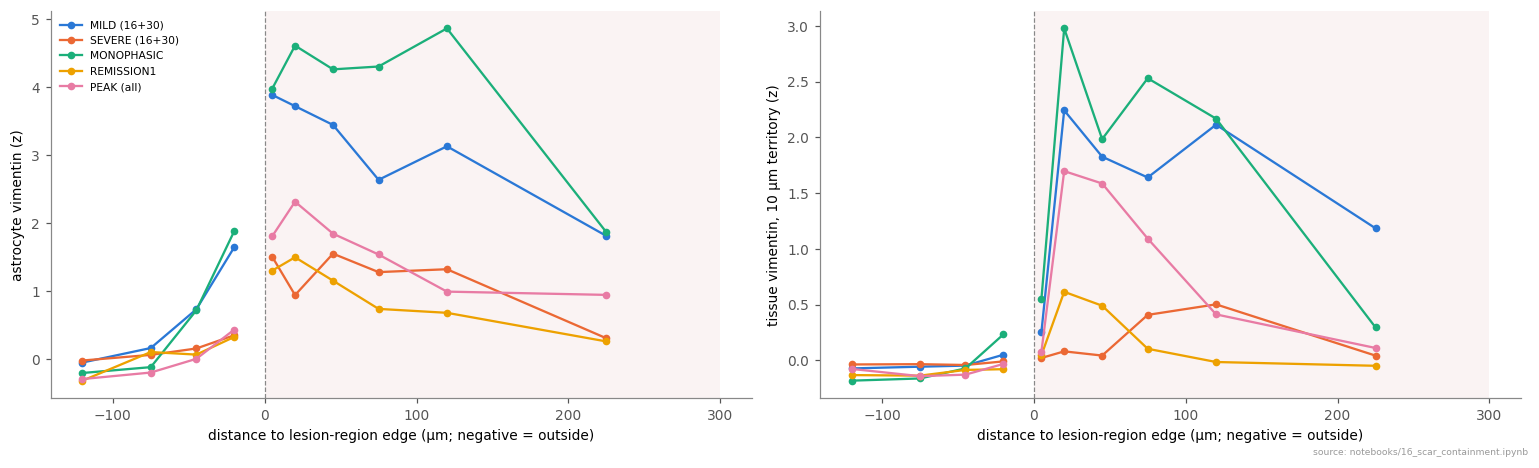

In [19]:
GROUPS = {"MILD (16+30)": obs.stage.isin(["MILD16", "MILD30"]), "SEVERE (16+30)": obs.stage.isin(["SEVERE16", "SEVERE30"]),
          "MONOPHASIC": obs.stage == "MONOPHASIC", "REMISSION1": obs.stage == "REMISSION1",
          "PEAK (all)": obs.stage.isin(["PEAK1", "PEAK2", "PEAK2_MILD", "PEAK3"])}
BINS = [-150, -90, -60, -30, -10, 0, 10, 30, 60, 90, 150, 300]
mids = [(a + b) / 2 for a, b in zip(BINS[:-1], BINS[1:])]
obs["rbin"] = pd.cut(obs.reg_dist, BINS)
fig, axs = plt.subplots(1, 2, figsize=(14, 4.2), sharex=True)
prof_rows = []
for ax, (lab, m0, val) in zip(axs, [("astrocyte vimentin (z)", obs.Anno_L1_curated == "Astrocyte", "vim_z"),
                                    ("tissue vimentin, 10 µm territory (z)", pd.Series(True, index=obs.index), "terr_vim_z")]):
    for k, (gname, gm) in enumerate(GROUPS.items()):
        d = obs[m0 & gm & obs.rbin.notna()]
        pa_ = d.groupby(["sample_name", "rbin"], observed=True)[val].agg(["median", "count"])
        med = pa_[pa_["count"] >= 15]["median"].unstack().median().reindex(obs.rbin.cat.categories)
        ax.plot(mids, med.values, marker="o", ms=4, color=COL[k], label=gname)
        prof_rows.append(pd.Series(med.values, index=[str(b) for b in obs.rbin.cat.categories], name=f"{lab} | {gname}"))
    ax.axvline(0, color="#888888", lw=0.8, ls="--"); ax.axvspan(0, 300, color="#f4e3e3", alpha=0.4, lw=0)
    ax.set(xlabel="distance to lesion-region edge (µm; negative = outside)", ylabel=lab)
axs[0].legend(fontsize=7)
fig.tight_layout()
plotting.save_fig(fig, "vimentin_edge_profiles_regions", OUT, SRC)
pd.DataFrame(prof_rows).round(2)

In [20]:
# per animal: vimentin inside lesion regions vs the same animal's tissue outside (> 60 µm away)
ast_ = obs.Anno_L1_curated == "Astrocyte"
inside_v = obs[ast_ & (obs.reg_dist > 0)].groupby("sample_name", observed=True).vim_z.median()
outside_v = obs[ast_ & (obs.reg_dist < -60)].groupby("sample_name", observed=True).vim_z.median()
iv = (inside_v - outside_v).rename("lesion-region − outside astrocyte vimentin").to_frame().join(an)
iv.to_csv(OUT / "region_inside_minus_outside_vimentin.csv")
iv.groupby("stage")["lesion-region − outside astrocyte vimentin"].agg(["median", "count"]).round(2)

,median,count
stage,,
MILD16,2.27,3
MILD30,3.30,5
MONOPHASIC,4.28,4
NONSYMPTOM,0.46,1
ONSET1,2.00,2
ONSET2,0.17,2
OS1,0.72,5
PEAK1,0.60,9
PEAK2,2.60,2


## Findings

> **Correction — the first lesion-level results were artefacts of the lesion objects.** Cells linked within 30 µm
> produce many diffuse "objects" (scattered lesion-called cells without a real outline), and the tissue-mask depth is
> wrong where roots or meninges are attached. With proper lesion **regions** (smoothed lesion-cell density, 356 regions,
> median 96 % lesion cells inside, real outlines; depth from the cord outline), the earlier claims do not hold: (i)
> within animals, border vimentin is **not** associated with immune cells around the lesion (median ρ 0.00, p = 0.65;
> deep regions ρ −0.39, n.s., 10 animals), so the data neither support nor refute containment; (ii) border vimentin
> does not clearly build from the chronic peak to MILD16 (0.67 → 0.50) and is lowest in SEVERE16 (0.02, p = 0.02 vs
> peak).
>
> **Finding — no vimentin ring; vimentin fills lesions in animals that do well.** With region outlines, vimentin rises
> on entering a lesion and stays high through the lesion interior; there is no edge peak (notebook 15's "ring" came
> from the cell-based distance, where "just inside the edge" meant isolated lesion cells in healthy tissue). Astrocyte
> vimentin inside lesion regions minus the same animal's tissue outside: PEAK1 0.60; MILD16 2.27 vs SEVERE16 1.01;
> MILD30 3.30 vs SEVERE30 2.07; MONOPHASIC 4.28 vs REMISSION1 1.26. So vimentin marks a lesion-wide astrocyte response
> that is low at peak and strongest in animals that recover: a resolution / gliosis phase, not a containment ring.